# <U>DEEP LEARNING AND GENERATIVE AI

## CA (Project) [50%]


## 0. INTRODUCTION

0.1. Student Name : <b>Vishal Chaudhary</b> <br>
0.2. Student ID : <b>23332794</b> <br>
0.3. Stduent Email : x23332794@student.ncirl.ie</b> <br>


1.1  Student Name : <b>Danish Mujibur Rehman</b> <br>
0.2. Student ID : <b>23425857</b> <br>
0.3. Stduent Email : x23425857@student.ncirl.ie <br>

# Title: Emotion Recognition from Images and Text using CNN & BERT Fusion
Goal: Predict a unified emotion from both a facial image and accompanying text using CNN + BERT fusion.

# 1. DATASETS


Dataset1: <b>GoEmotions </b><br>
Number of examples: 58,009. <br>
Number of labels: 27 + Neutral. <br>
Size of training dataset: 43,410. <br>
Size of test dataset: 5,427. <br>
Size of validation dataset: 5,426. <br>
The emotion categories are: admiration, amusement, anger, annoyance, approval, caring, confusion, curiosity, desire, disappointment, disapproval, disgust, embarrassment, excitement, fear, gratitude, grief, joy, love, nervousness, optimism, pride, realization, relief, remorse, sadness, surprise. <br>

Dataset2: <b>Young AffectNet HQ</b> <br>
Age was set at 5, 10, 15 years.The dataset was used to train emotion recognition models in this project. <br>

# 2. MODULE INSTALLATION 

In [87]:
pip install tensorflow transformers scikit-learn pandas matplotlib opencv-python wordcloud


Note: you may need to restart the kernel to use updated packages.


# 3. MODULE IMPORT 

In [49]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt

# 4.  MAPPING GOEMOTIONS LABELS TO MATCH 8 YOUNG AFFECTNET EMOTION CATEGORIES

In [3]:
# Loading GoEmotions training dataset
''' First we have to map goemotions (multilevel emotions) with young affectnet 8-class labels'''
emotions_df = pd.read_csv('train.tsv', sep='\t', names=['text', 'labels', 'id'])

In [4]:
# Loading the orignal list of emotion labels
with open('emotions.txt', 'r') as f:
    emotion_labels = [line.strip() for line in f.readlines()]


In [5]:
# Labelling goemotions (multi_label) to young affectnet 8-class labels
label_mapping = {'anger': 'anger','annoyance': 'anger','disapproval': 'anger','contempt': 'contempt','disgust': 'disgust',
'fear': 'fear','nervousness': 'fear','joy': 'happy','amusement': 'happy','excitement': 'happy','love': 'happy',
'pride': 'happy','neutral': 'neutral','sadness': 'sad','disappointment': 'sad','grief': 'sad','remorse': 'sad',
'surprise': 'surprise','realization': 'surprise',}


In [6]:
def map_emotion(emotions_indices):
    try:
        if isinstance(emotions_indices, str):
            emotions_indices = ast.literal_eval(emotions_indices)
    except:
        return []  

    if isinstance(emotions_indices, int):
        emotions_indices = [emotions_indices]

    mapped = set()
    for idx in emotions_indices:
        if 0 <= idx < len(emotion_labels):
            emo = emotion_labels[idx]
            if emo in label_mapping:
                mapped.add(label_mapping[emo])
    return list(mapped)

In [7]:
emotions_df['mapped_emotions'] = emotions_df['labels'].apply(map_emotion)

In [8]:
# Filtering emotions to single-label rows only
emotions_df = emotions_df[emotions_df['mapped_emotions'].map(len) == 1]
emotions_df['final_emotion'] = emotions_df['mapped_emotions'].str[0]


In [9]:
final_emotions_df = emotions_df[['text', 'final_emotion']].reset_index(drop=True)
final_emotions_df.to_csv('emotions_mapped.csv', index=False)
''' Label mapping of goemotions according to young affect images data labels is complete.'''

' Label mapping of goemotions according to young affect images data labels is complete.'

In [46]:
# Text count by emotions
text_counts = emotions_df['final_emotion'].value_counts()

print("Text Counts by Emotion:")
for emotion, count in text_counts.items():
    print(f"  {emotion}: {count} texts")


Text Counts by Emotion:
  neutral: 13464 texts
  happy: 5941 texts
  anger: 4662 texts
  sad: 2407 texts
  surprise: 1716 texts
  fear: 599 texts
  disgust: 547 texts


In [48]:
print(f"\nTotal number of text found: {len(emotions_df)}")


Total number of text found: 29336


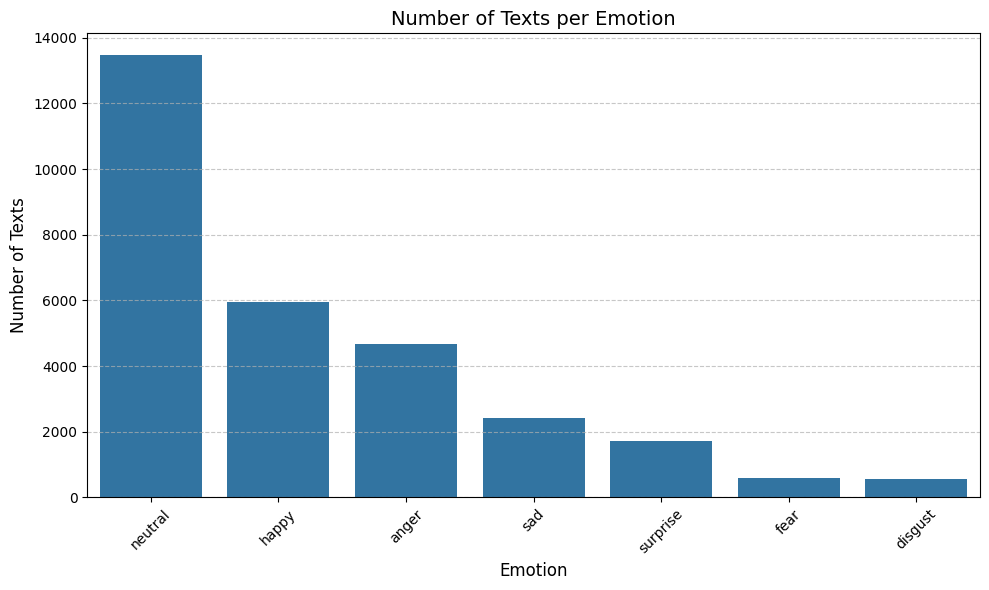

In [51]:
text_counts = emotions_df['final_emotion'].value_counts().sort_values(ascending=False)

# bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=text_counts.index, y=text_counts.values)

plt.title("Number of Texts per Emotion", fontsize=14)
plt.xlabel("Emotion", fontsize=12)
plt.ylabel("Number of Texts", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Number_of_Texts_per_Emotion.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. PAIRING TEXT WITH IMAGES- (PREPARING FINAL DATASET)

In [10]:
import os
import random


In [11]:
print(os.getcwd())


/Users/vishalchaudhary/Desktop/College_modules/Deep Learning/project


In [12]:
image_base_dir = '/Users/vishalchaudhary/Desktop/College_modules/Deep Learning/project/Images'
emotions_csv_path = '/Users/vishalchaudhary/Desktop/College_modules/Deep Learning/project/goemotions_mapped.csv'
output_csv_path = '/Users/vishalchaudhary/Desktop/College_modules/Deep Learning/project/paired_dataset.csv'

In [52]:
# Total number of Images by emotion
image_extensions = ('.jpg', '.jpeg', '.png')
image_counts = {}
# Total image counter
total_images = 0

In [53]:
# Loop through each subfolder (assumed to be emotions)
for emotion in os.listdir(image_base_dir):
    folder_path = os.path.join(image_base_dir, emotion)

    if not os.path.isdir(folder_path):
        continue  

    images = [f for f in os.listdir(folder_path) if f.lower().endswith(image_extensions)]
    count = len(images)
    image_counts[emotion] = count
    total_images += count

In [54]:
# Print the counts per emotion
print("Count of Images by Emotion:")
for emotion, count in image_counts.items():
    print(f"  {emotion}: {count} images")

# Print the total
print(f"\nTotal number of images: {total_images}")

Count of Images by Emotion:
  happy: 1862 images
  contempt: 1833 images
  sad: 1821 images
  fear: 1839 images
  surprise: 1851 images
  neutral: 1880 images
  anger: 1822 images
  disgust: 1740 images

Total number of images: 14648


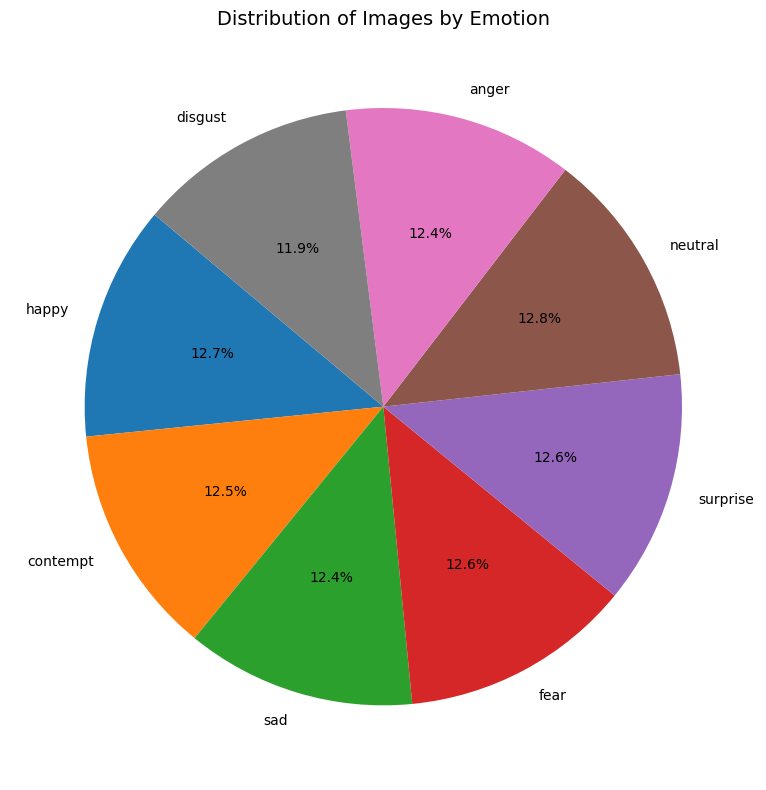

In [60]:
# Prepare data for pie chart
emotions = list(image_counts.keys())
counts = list(image_counts.values())

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=emotions, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Images by Emotion', fontsize=14)
plt.tight_layout()
plt.savefig('Distribution of Images by Emotion.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
emotion_df = pd.read_csv(emotions_csv_path)

In [14]:
paired_data = []

In [15]:
# gropping text data by emotion
emotion_groups = emotion_df.groupby('final_emotion')


In [16]:
# Loop for each emotion folder in the image directory
for emotion in os.listdir(image_base_dir):
    emotion_path = os.path.join(image_base_dir, emotion)

    if not os.path.isdir(emotion_path):
        continue  

    image_files = [f for f in os.listdir(emotion_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    if not image_files:
        continue  

    if emotion not in emotion_groups.groups:
        print(f"No matching text found for emotion '{emotion}' — skip.")
        continue

    emotion_texts = emotion_groups.get_group(emotion)

    image_files = random.sample(image_files, len(image_files))
    emotion_texts = emotion_texts.sample(frac=1).reset_index(drop=True)

    min_len = min(len(image_files), len(emotion_texts))

    for i in range(min_len):
        image_path = os.path.join(emotion, image_files[i]) 
        text = emotion_texts.iloc[i]['text']
        paired_data.append({
            'image_path': image_path,
            'text': text,
            'emotion': emotion
        })

No matching text found for emotion 'contempt' — skip.


In [17]:
paired_df = pd.DataFrame(paired_data)
paired_df.to_csv(output_csv_path, index=False)
print(f" Paired {len(paired_df)} samples saved to '{output_csv_path}'")


 Paired 10247 samples saved to '/Users/vishalchaudhary/Desktop/College_modules/Deep Learning/project/paired_dataset.csv'


In [57]:
pair_df = pd.read_csv('/Users/vishalchaudhary/Desktop/College_modules/Deep Learning/project/paired_dataset.csv')


In [58]:
print(pair_df.columns)

Index(['image_path', 'text', 'emotion'], dtype='object')


In [59]:
# total number of paired samples
print(f"Total number of Paired Samples: {len(pair_df)}")

# Count per emotion
print("\n Paired Samples per Emotion:")
print(pair_df['emotion'].value_counts())


Total number of Paired Samples: 10247

 Paired Samples per Emotion:
emotion
neutral     1880
happy       1862
anger       1822
sad         1821
surprise    1716
fear         599
disgust      547
Name: count, dtype: int64


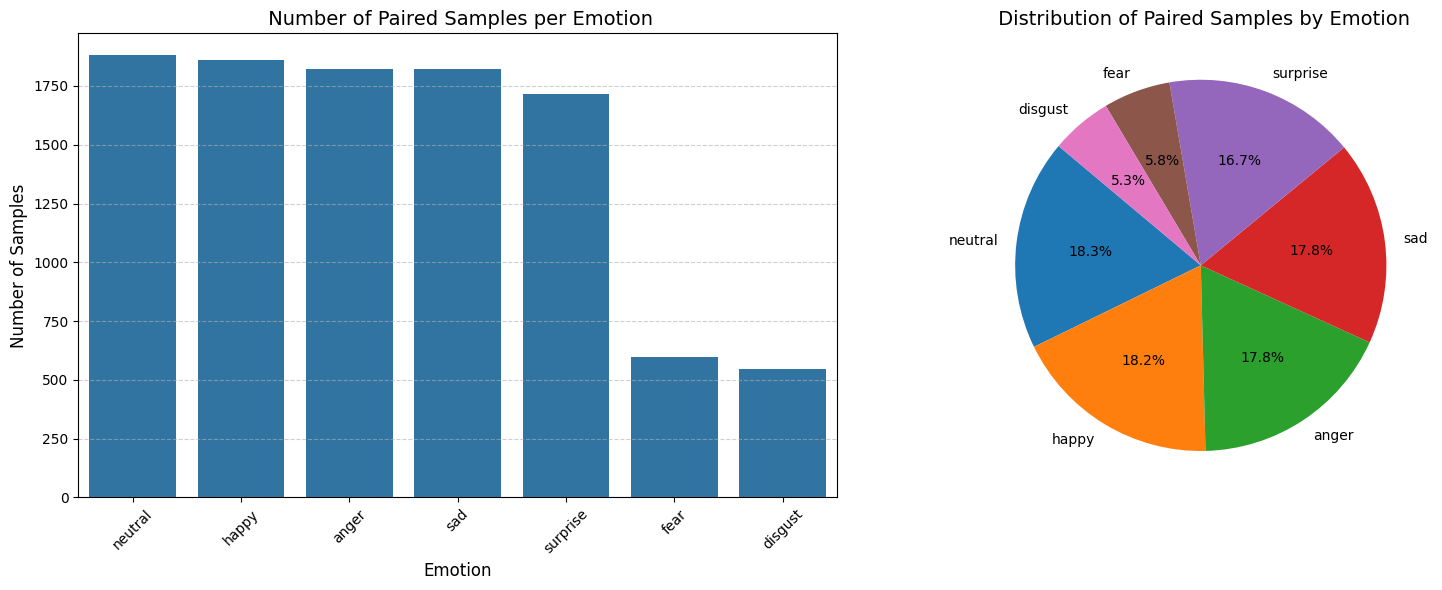

In [61]:
# Count sample numbers per emotion
emotion_counts = pair_df['emotion'].value_counts().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, ax=axes[0])
axes[0].set_title(' Number of Paired Samples per Emotion', fontsize=14)
axes[0].set_xlabel('Emotion', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Pie chart
axes[1].pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%', startangle=140)
axes[1].set_title(' Distribution of Paired Samples by Emotion', fontsize=14)

plt.tight_layout()
plt.savefig('Distribution of Paired Samples by Emotion.png', dpi=300, bbox_inches='tight')
plt.show()

# IMPORT LIBRARIES

In [21]:
import os
import pandas as pd
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import BertTokenizer, TFBertModel
import numpy as np


# 6. Emotion Recognition from Images and Text (Multimodal Fusion Model)

In [24]:
# Loding final paired dataset 
df = pd.read_csv('paired_dataset.csv')

#### 6.1 Encode Emotion Labels

In [25]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['emotion'])
emotion_classes = list(le.classes_)


#### 6.2 Split Data into Train, Validation, and Test

In [27]:
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(test_df, test_size=0.5, stratify=test_df['label'], random_state=42)


#### 6.3 Preprocessing Functions

In [28]:
IMG_SIZE = (224, 224)
MAX_LEN = 64
BATCH_SIZE = 32
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')


##### 6.3.1 Image Preprocessing:

In [29]:
def process_image(img_path):
    image = tf.io.read_file(img_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    return image / 255.0


##### 6.3.2 Text Tokenization (BERT):

In [30]:
def encode_text(text):
    tokens = tokenizer(text,
                       max_length=MAX_LEN,
                       padding='max_length',
                       truncation=True,
                       return_tensors='tf')
    return tokens['input_ids'][0], tokens['attention_mask'][0]


#### 6.4 Creating Tensorflow Datasets

In [31]:
def create_dataset(dataframe):
    def gen():
        for _, row in dataframe.iterrows():
            img_path = os.path.join('Images', row['image_path'])  # make sure relative path works
            text = row['text']
            label = row['label']
            try:
                image = process_image(img_path)
                input_ids, att_mask = encode_text(text)
                yield (image, input_ids, att_mask), label
            except:
                continue  # Skip faulty data

    return tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            (
                tf.TensorSpec(shape=(224, 224, 3), dtype=tf.float32),
                tf.TensorSpec(shape=(MAX_LEN,), dtype=tf.int32),
                tf.TensorSpec(shape=(MAX_LEN,), dtype=tf.int32)
            ),
            tf.TensorSpec(shape=(), dtype=tf.int64)
        )
    ).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


#### 6.5 Prepare datasets

In [33]:
train_ds = create_dataset(train_df)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)


#### 6.6 Building Fusion Modal(CNN + BERT)

##### 6.6.1 Image branch (CNN):

In [37]:
image_input = tf.keras.Input(shape=(224, 224, 3), name='image_input')
cnn_base = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_tensor=image_input)
cnn_base.trainable = False  
cnn_out = tf.keras.layers.GlobalAveragePooling2D()(cnn_base.output)
cnn_out = tf.keras.layers.Dense(128, activation='relu')(cnn_out)


##### 6.6.2 Text branch (BERT):

In [38]:
input_ids = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='input_ids')
attention_mask = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='attention_mask')
bert_model = TFBertModel.from_pretrained('bert-base-uncased')
bert_out = bert_model(input_ids, attention_mask=attention_mask)[1]
bert_out = tf.keras.layers.Dense(128, activation='relu')(bert_out)


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were 

##### 6.6.3 Fusion + Output:

In [39]:
fusion = tf.keras.layers.Concatenate()([cnn_out, bert_out])
fusion = tf.keras.layers.Dense(64, activation='relu')(fusion)
output = tf.keras.layers.Dense(len(emotion_classes), activation='softmax')(fusion)

model = tf.keras.Model(inputs=[image_input, input_ids, attention_mask], outputs=output)


#### 6.7 Compiling the Model

In [41]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### 6.8 Model Training

In [43]:
history = model.fit(train_ds, validation_data=val_ds, epochs=5)


Epoch 1/5


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


    257/Unknown - 1573s 6s/step - loss: 1.3334 - accuracy: 0.5214

2025-07-18 13:39:05.335210: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


257/257 [==============================] - 1841s 7s/step - loss: 1.3334 - accuracy: 0.5214 - val_loss: 0.9824 - val_accuracy: 0.6654
Epoch 2/5


2025-07-18 13:43:33.254453: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


257/257 [==============================] - 1184s 5s/step - loss: 0.7482 - accuracy: 0.7559 - val_loss: 0.9206 - val_accuracy: 0.6956
Epoch 3/5
257/257 [==============================] - 1136s 4s/step - loss: 0.5112 - accuracy: 0.8382 - val_loss: 0.9643 - val_accuracy: 0.6927
Epoch 4/5
257/257 [==============================] - 1214s 5s/step - loss: 0.3446 - accuracy: 0.8976 - val_loss: 1.0804 - val_accuracy: 0.6898
Epoch 5/5
257/257 [==============================] - 1332s 5s/step - loss: 0.2366 - accuracy: 0.9290 - val_loss: 1.1500 - val_accuracy: 0.6946


#### 6.9 Evaluate on Test Set

In [44]:
loss, acc = model.evaluate(test_ds)
print(f"\n Test Accuracy: {acc * 100:.2f}%")


33/33 [==============================] - 44s 1s/step - loss: 1.0634 - accuracy: 0.6995

 Test Accuracy: 69.95%


In [113]:
from sklearn.metrics import f1_score, precision_score, recall_score

y_true = []
y_pred = []

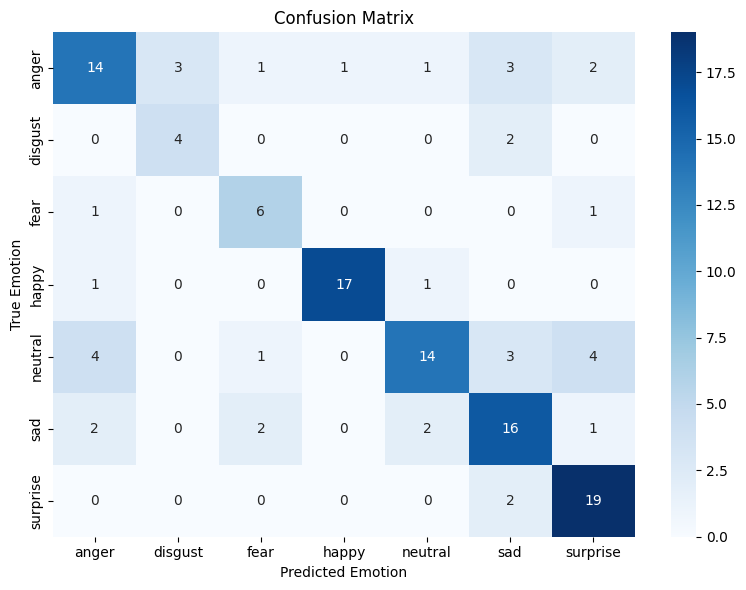

In [67]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_classes,
            yticklabels=emotion_classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()


In [116]:
# Calculate F1-score (macro and weighted)
macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

print(f"\n Macro F1-score: {macro_f1:.4f}")
print(f" Weighted F1-score: {weighted_f1:.4f}")


 Macro F1-score: 0.7170
 Weighted F1-score: 0.7227


#### 6.10 Save Model

In [45]:
model.save("multimodal_emotion_model.h5")
print("Model will be saved as 'multimodal_emotion_model.h5'")


/opt/anaconda3/lib/python3.12/site-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model will be saved as 'multimodal_emotion_model.h5'


#### 6.11 Training & Validation Accuracy

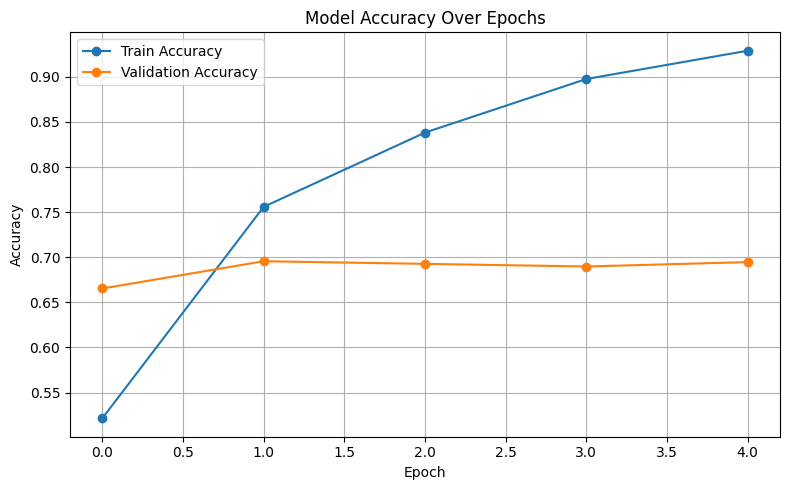

In [109]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('model_accuracy.png')
plt.show()


#### 6.12 Training & Validation Loss

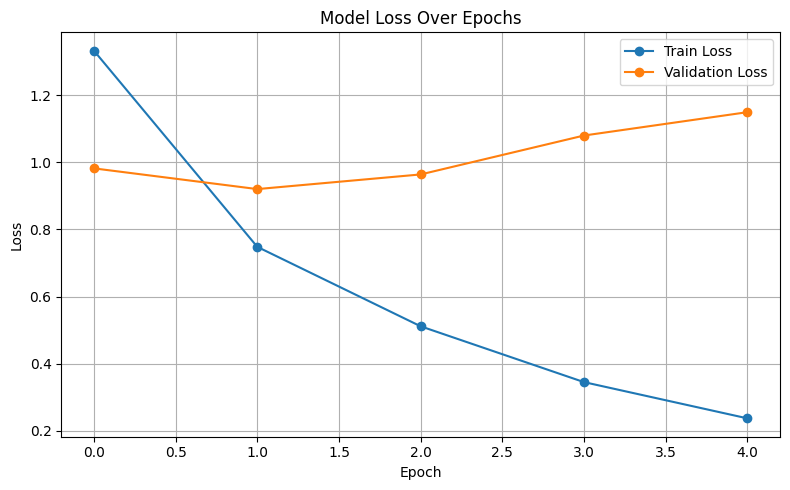

In [110]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('model_loss.png')  
plt.show()


#### 6.13 Testing Model

1/1 [==============================] - 0s 79ms/step


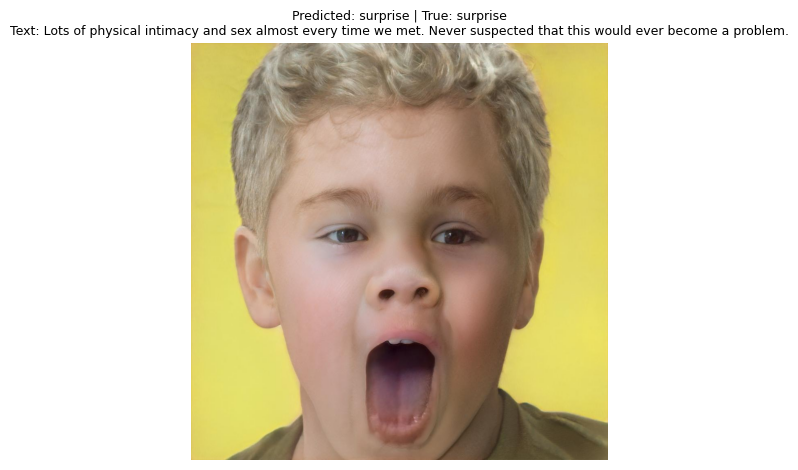

In [99]:
# Select a few random samples from test set
sample_df = test_df.sample(n=1).reset_index(drop=True)

for i in range(len(sample_df)):
    row = sample_df.iloc[i]
    image_path = os.path.join("Images", row['image_path'])
    text = row['text']
    true_label = row['emotion']

    # Preprocess inputs
    img = tf.expand_dims(process_image(image_path), axis=0)
    input_ids, att_mask = encode_text(text)
    input_ids = tf.expand_dims(input_ids, axis=0)
    att_mask = tf.expand_dims(att_mask, axis=0)

    # Predict
    pred = model.predict([img, input_ids, att_mask])
    pred_label = emotion_classes[np.argmax(pred)]

    # Show
    image = plt.imread(image_path)
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Predicted: {pred_label} | True: {true_label}\nText: {text}", fontsize=9)
    plt.tight_layout()
    plt.savefig('prediction vs reality(emotion).png')
    plt.show()


1/1 [==============================] - 0s 73ms/step


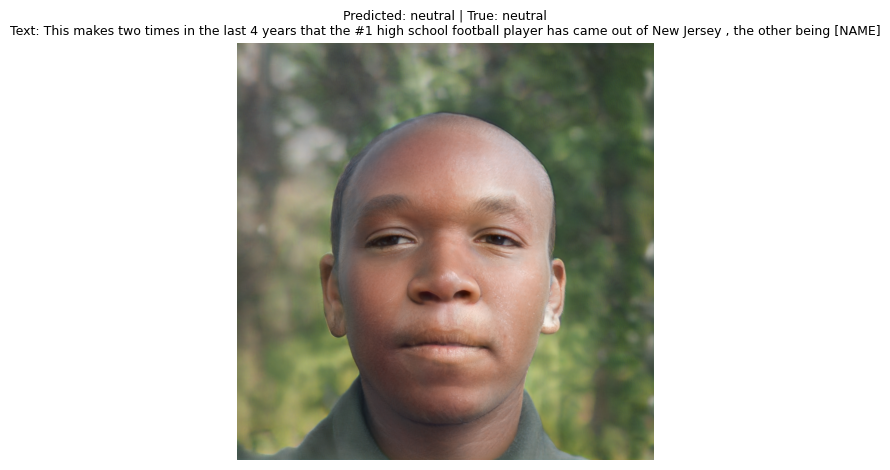

In [103]:

sample_df = test_df.sample(n=1).reset_index(drop=True)

for i in range(len(sample_df)):
    row = sample_df.iloc[i]
    image_path = os.path.join("Images", row['image_path'])
    text = row['text']
    true_label = row['emotion']

    # Preprocess inputs
    img = tf.expand_dims(process_image(image_path), axis=0)
    input_ids, att_mask = encode_text(text)
    input_ids = tf.expand_dims(input_ids, axis=0)
    att_mask = tf.expand_dims(att_mask, axis=0)

    # Predict
    pred = model.predict([img, input_ids, att_mask])
    pred_label = emotion_classes[np.argmax(pred)]

    # Show
    image = plt.imread(image_path)
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Predicted: {pred_label} | True: {true_label}\nText: {text}", fontsize=9)
    plt.tight_layout()
    plt.savefig('prediction vs reality(emotion1).png')
    plt.show()


1/1 [==============================] - 0s 136ms/step


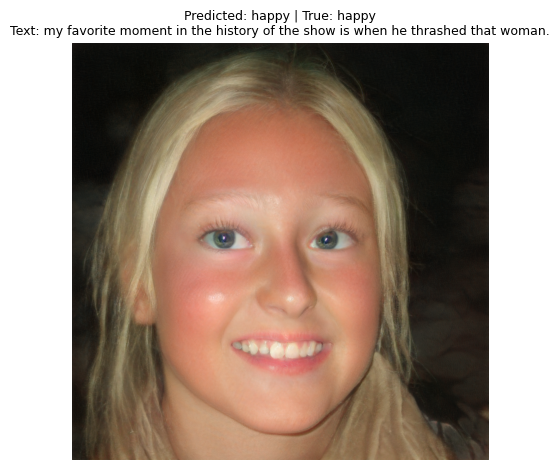

In [108]:

sample_df = test_df.sample(n=1).reset_index(drop=True)

for i in range(len(sample_df)):
    row = sample_df.iloc[i]
    image_path = os.path.join("Images", row['image_path'])
    text = row['text']
    true_label = row['emotion']

    # Preprocess inputs
    img = tf.expand_dims(process_image(image_path), axis=0)
    input_ids, att_mask = encode_text(text)
    input_ids = tf.expand_dims(input_ids, axis=0)
    att_mask = tf.expand_dims(att_mask, axis=0)

    # Predict
    pred = model.predict([img, input_ids, att_mask])
    pred_label = emotion_classes[np.argmax(pred)]

    # Show
    image = plt.imread(image_path)
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Predicted: {pred_label} | True: {true_label}\nText: {text}", fontsize=9)
    plt.tight_layout()
    plt.savefig('prediction vs reality(emotion2).png')
    plt.show()


#### 6.14 Wordcloud

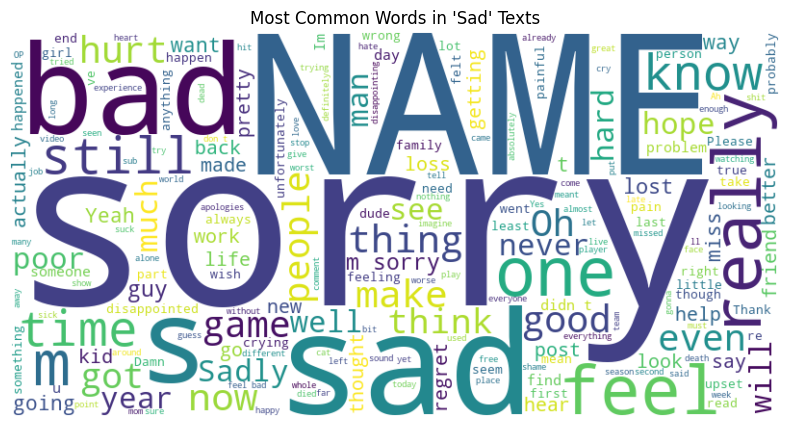

In [119]:
from wordcloud import WordCloud

# Showing word importance based on text frequency per emotion (sad)
sad_texts = df[df['emotion'] == 'sad']['text'].str.cat(sep=' ')
wc = WordCloud(width=800, height=400, background_color='white').generate(sad_texts)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in 'Sad' Texts")
plt.savefig('wordcloud_sad.png')
plt.show()


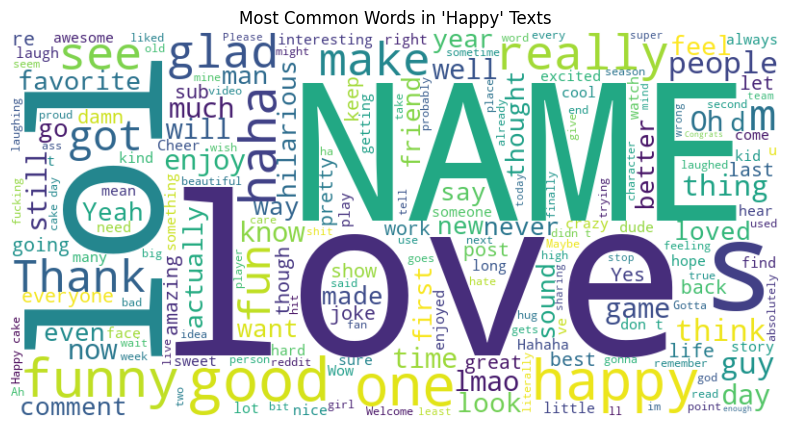

In [92]:
happy_texts = df[df['emotion'] == 'happy']['text'].str.cat(sep=' ')
wc = WordCloud(width=800, height=400, background_color='white').generate(happy_texts)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in 'Happy' Texts")
plt.savefig('wordcloud_happy.png')
plt.show()